In [2]:
import sys, os
from pathlib import Path
import warnings 
warnings.filterwarnings("ignore")

# --- robust project root detection ---
CWD = Path.cwd()
PROJECT_ROOT = next((p for p in [CWD] + list(CWD.parents) if (p / "preprocessing").exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find PROJECT_ROOT (no 'preprocessing/' directory found in parents).")

# Make imports work + ensure relative paths are consistent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)

import pandas as pd
from sqlalchemy.dialects.mssql.information_schema import columns

from analysis.metabolite_level_analysis import (
    analyse_with_logistic_regression,
    calculate_odds_ratio,
    calculate_hazard_ratio,
    prepare_duration,
    create_ages_df,
    create_ages_df_with_df
)

from preprocessing import (
    MetaboliteLevelsPreprocessorFactory,
    PathwayPreprocessorFactory,
    ReactionPreprocessorFactory,
    MetabolitePathwayCombinedPreprocessorFactory,
    MetaboliteReactionCombinedPreprocessorFactory,
    TranscriptomicsPreprocessorFactory,
    TranscriptomicsMetabolitePreprocessorFactory,
    TranscriptomicsPathwayPreprocessorFactory,
    TranscriptomicsReactionPreprocessorFactory
)

CWD: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis


In [6]:
from analysis.cox_regression import compute_hazard_ratios
from analysis import calculate_risk_score_with_best_prs
import pandas as pd
from sklearn.preprocessing import StandardScaler

from analysis.config import make_default_paths
# dataset root
DATA_DIR = PROJECT_ROOT / "ROSMAP-AD"
paths = make_default_paths(DATA_DIR)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
metabolite_levels_file_path = paths.metabolite_levels_file_path

prs_combined = paths.prs_combined_path
pathway_file_path = paths.pathway_file_path
reaction_file_path = paths.reaction_file_path
metabolite_level_pathway_combined_file_path = paths.metabolite_level_pathway_combined_file_path
metabolite_level_reaction_combined_file_path = paths.metabolite_level_reaction_combined_file_path
x_pathway_path = paths.x_pathway_path
x_reaction_path = paths.x_reaction_path
best_prs_path = paths.best_prs_path
clinical_ages_path = paths.clinical_ages_path

factory_list = [
    MetaboliteLevelsPreprocessorFactory(metabolite_levels_file_path),
    PathwayPreprocessorFactory(metabolite_levels_file_path, pathway_file_path, x_pathway_path),
    ReactionPreprocessorFactory(metabolite_levels_file_path, reaction_file_path, x_reaction_path),
    MetabolitePathwayCombinedPreprocessorFactory(metabolite_levels_file_path, metabolite_level_pathway_combined_file_path, x_pathway_path),
    MetaboliteReactionCombinedPreprocessorFactory(metabolite_levels_file_path, metabolite_level_reaction_combined_file_path, x_reaction_path),
]

general_df = pd.DataFrame()
for factory in factory_list:
    preprocessor = factory.create_preprocessor()
    y, risk_scores, sample_ids_ = analyse_with_logistic_regression(preprocessor)
    biomarker_df = pd.DataFrame({
        preprocessor.name: risk_scores,
        'sample_id': sample_ids_
    })
    if 'sample_id' not in general_df.columns:
        general_df['sample_id'] = sample_ids_

    general_df = pd.merge(general_df, biomarker_df, on='sample_id')

    combined_risk_df = calculate_risk_score_with_best_prs(y, risk_scores, sample_ids_, best_prs_path, prs_combined)
    combined_risk_df = combined_risk_df[['sample_id_biomarker', 'combined_score']]
    combined_risk_df.rename(columns={'combined_score': f"{preprocessor.name} PRS", 'sample_id_biomarker': 'sample_id'}, inplace=True)
    general_df = pd.merge(general_df, combined_risk_df, on='sample_id', how='inner')

prs_df = pd.read_csv(best_prs_path)
prs_df.rename(columns={'score': 'PRS'}, inplace=True)
scaler = StandardScaler()
prs_df["PRS"] = scaler.fit_transform(prs_df[["PRS"]])

general_df = pd.merge(general_df, prs_df, on='sample_id', how='inner')
general_df.to_csv('ROSMAP-AD/processed/general_df_2.csv', index=False)

PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/ROSMAP-AD


Index(['Metabolite Levels', 'Metabolite Levels PRS', 'Pathway Diff Scores',
       'Pathway Diff Scores PRS', 'Reaction Diff Scores',
       'Reaction Diff Scores PRS', 'Metabolite Levels Pathway Combined',
       'Metabolite Levels Pathway Combined PRS',
       'Metabolite Levels Reaction Combined',
       'Metabolite Levels Reaction Combined PRS', 'PRS'],
      dtype='str')


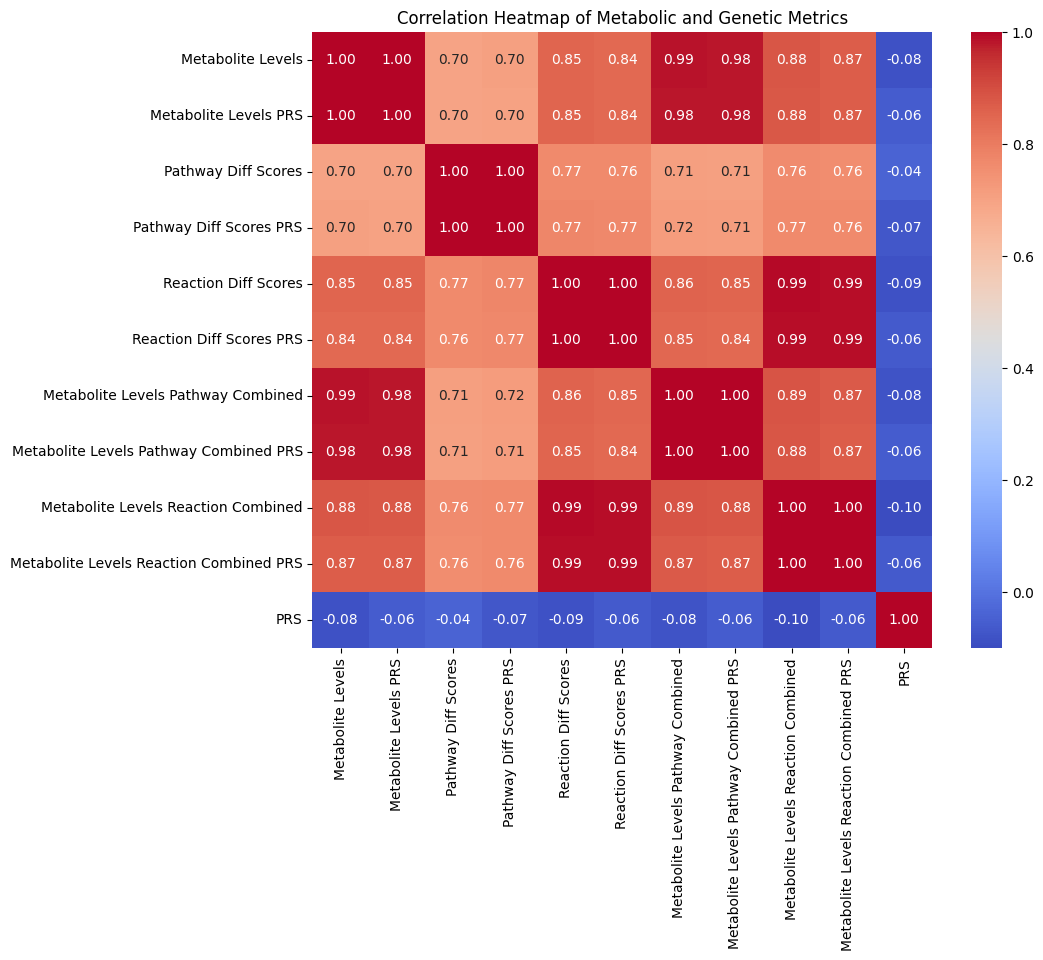

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

general_df = general_df.drop(columns=['sample_id'])
print(general_df.columns)
corr = general_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Metabolic and Genetic Metrics")
plt.show()

In [12]:
from analysis.cox_regression import compute_hazard_ratios
from analysis import calculate_risk_score_with_best_prs
import pandas as pd
from analysis import calculate_risk_score_with_prs
from sklearn.preprocessing import StandardScaler
import os
import glob

# Path to the main folder
main_folder = 'ROSMAP-AD/Final_Prs_Scores'

df_dict = {}
for subfolder in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, subfolder)
    general_df = pd.DataFrame()
    if os.path.isdir(subfolder_path):
        prs_id = subfolder
        csv_path = os.path.join(subfolder_path, 'prs_scores.csv')
        prs_scores = pd.read_csv(csv_path)               # Contains individual IDs and scores
        rosmap_clinical = pd.read_csv('ROSMAP-AD/raw/clinical.csv')     # Contains ID, Study, and projid

        # Merge on individual ID
        rosmap_clinical['sample_id'] = rosmap_clinical['Sample ID'].astype(str)
        merged = prs_scores.merge(rosmap_clinical, on='sample_id', how='inner')
        prs_df = merged[['sample_id', 'score']]

        for factory in factory_list:
            preprocessor = factory.create_preprocessor()
            y, risk_scores, sample_ids_ = analyse_with_logistic_regression(preprocessor)
            biomarker_df = pd.DataFrame({
                preprocessor.name: risk_scores,
                'sample_id': sample_ids_
            })
            if 'sample_id' not in general_df.columns:
                general_df['sample_id'] = sample_ids_

            general_df = pd.merge(general_df, biomarker_df, on='sample_id')

            combined_risk_df = calculate_risk_score_with_prs(y, risk_scores, sample_ids_, prs_df, prs_combined)
            combined_risk_df = combined_risk_df[['sample_id_biomarker', 'combined_score']]
            combined_risk_df.rename(columns={'combined_score': f"{preprocessor.name} PRS", 'sample_id_biomarker': 'sample_id'}, inplace=True)
            general_df = pd.merge(general_df, combined_risk_df, on='sample_id', how='inner')

        prs_df = pd.read_csv(best_prs_path)
        prs_df.rename(columns={'score': 'PRS'}, inplace=True)
        scaler = StandardScaler()
        prs_df["PRS"] = scaler.fit_transform(prs_df[["PRS"]])

        general_df = pd.merge(general_df, prs_df, on='sample_id', how='inner')
        general_df.to_csv('ROSMAP-AD/processed/general_df_2.csv', index=False)
        df_dict[subfolder] = general_df

KeyboardInterrupt: 

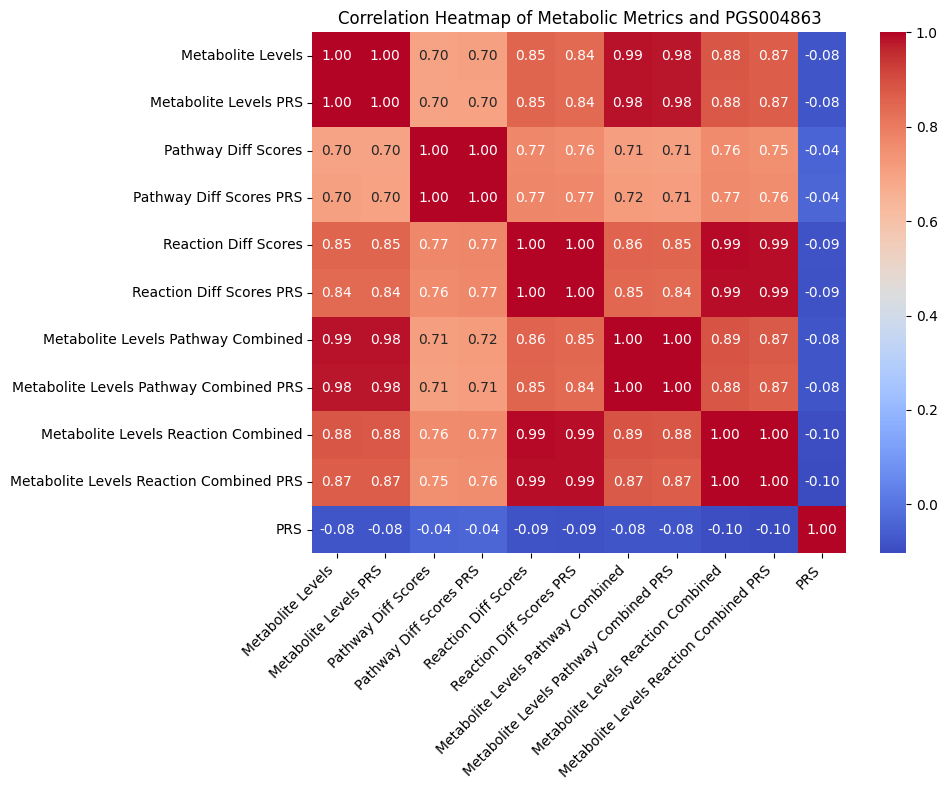

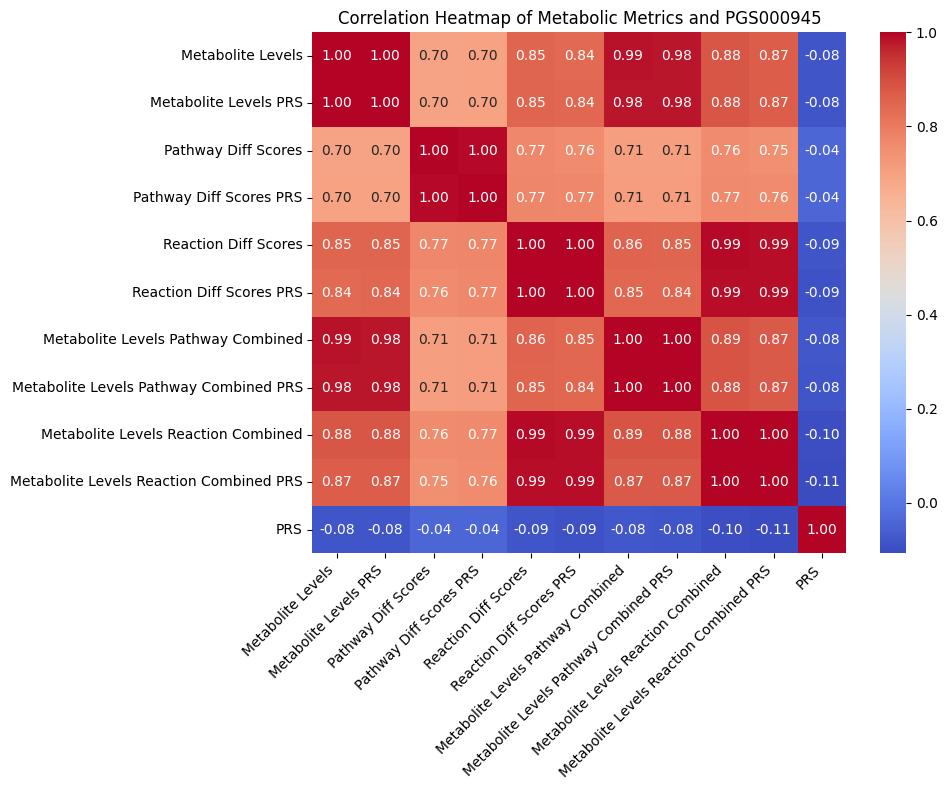

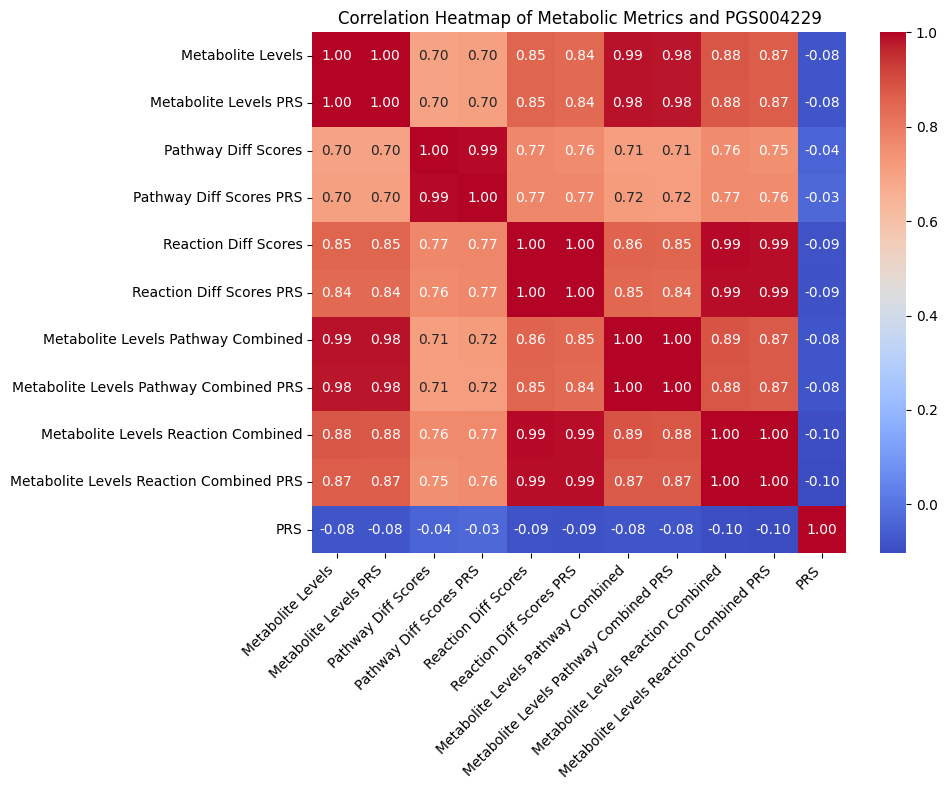

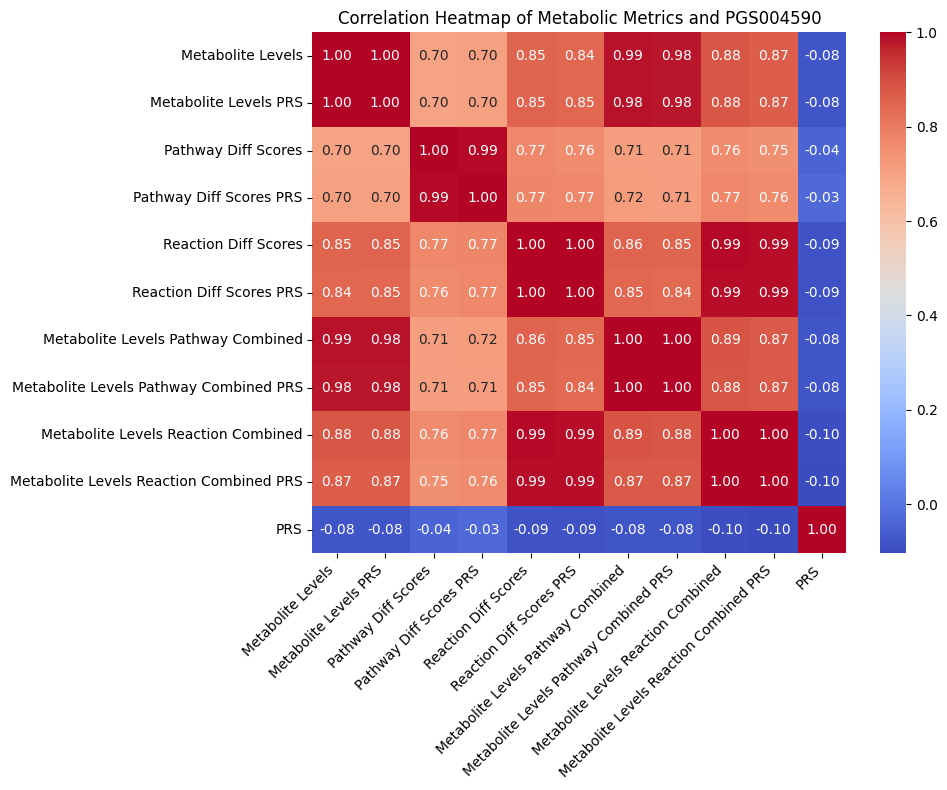

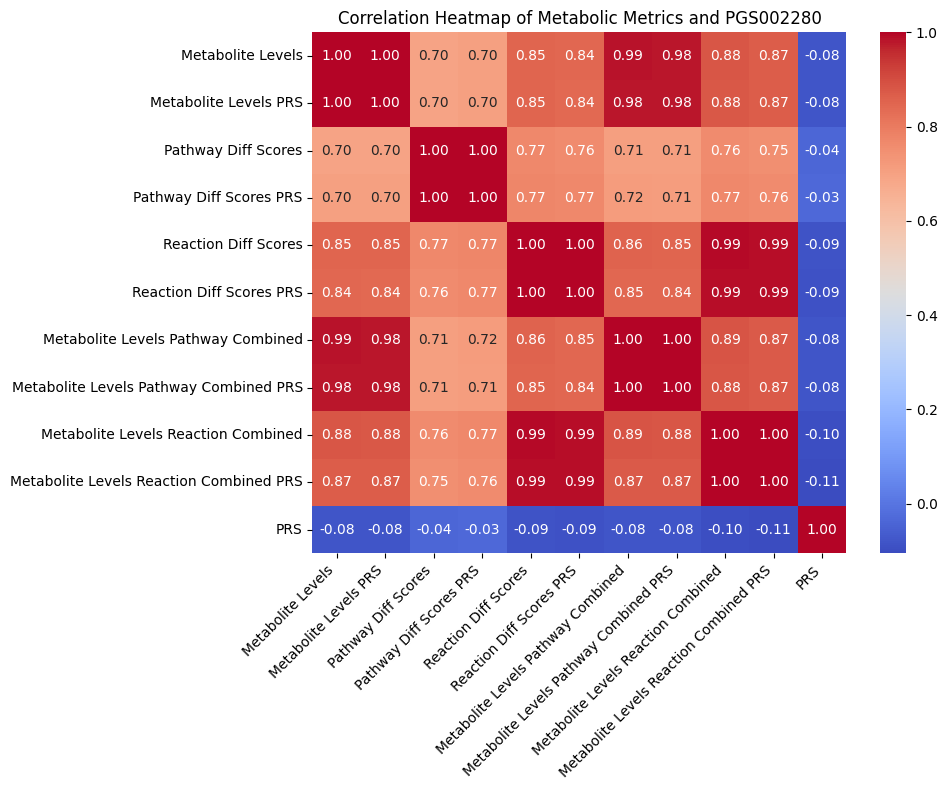

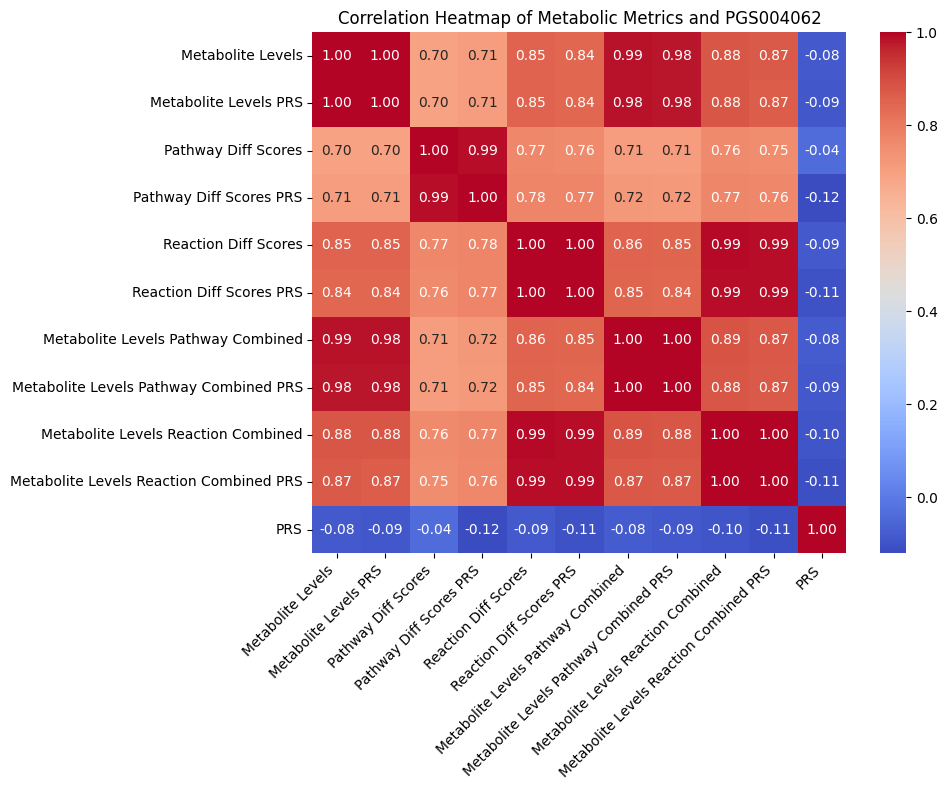

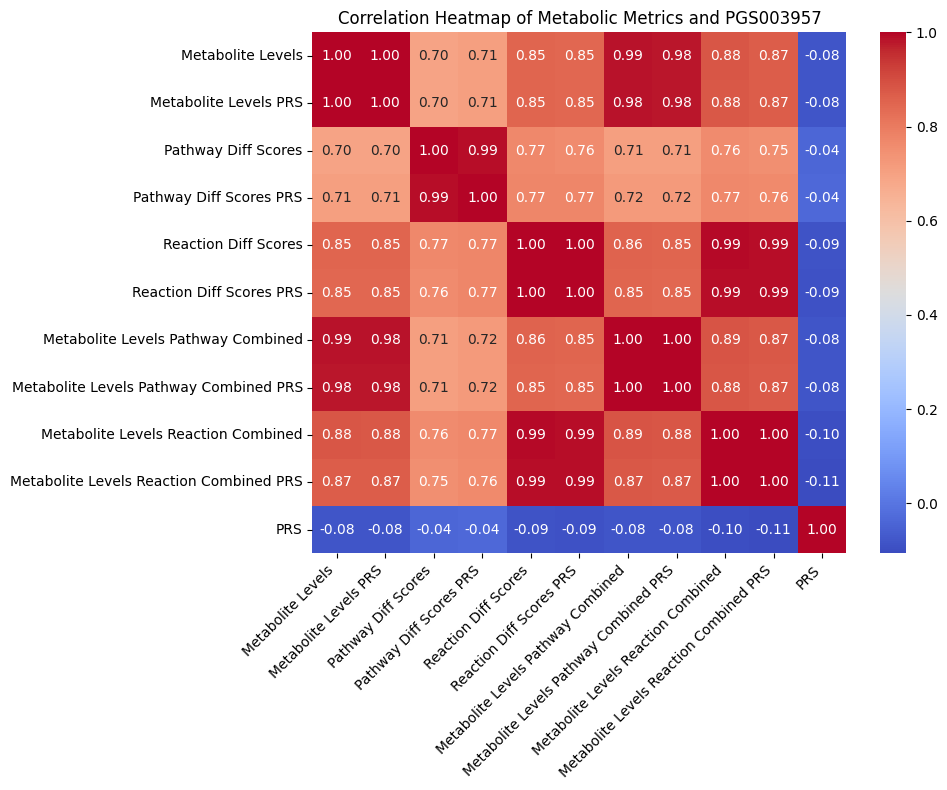

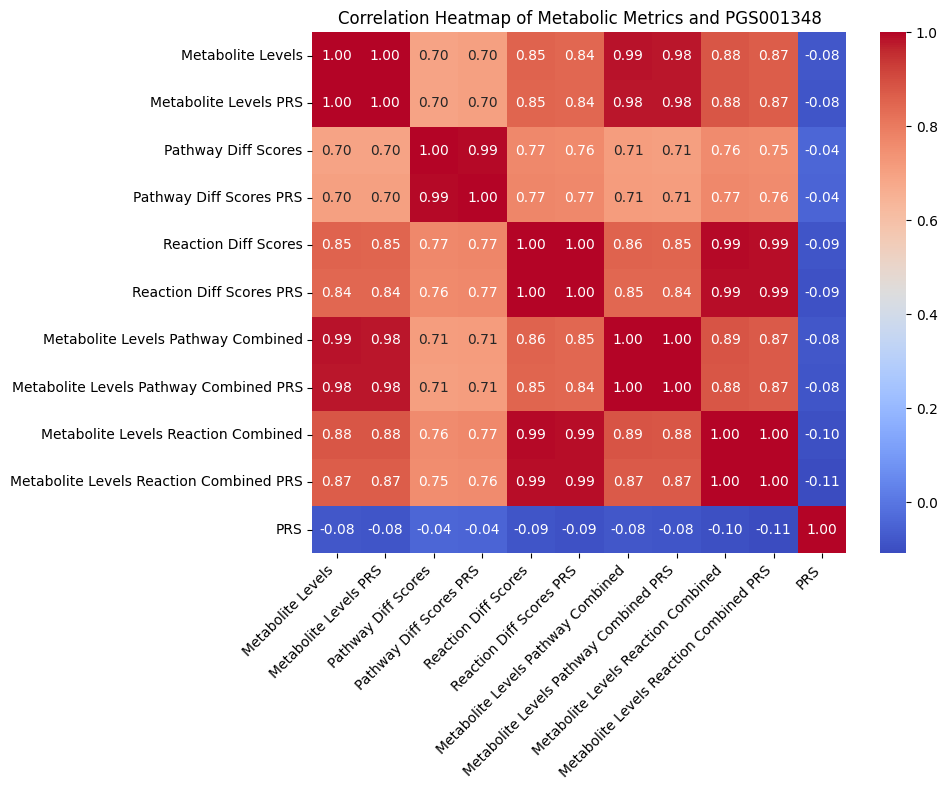

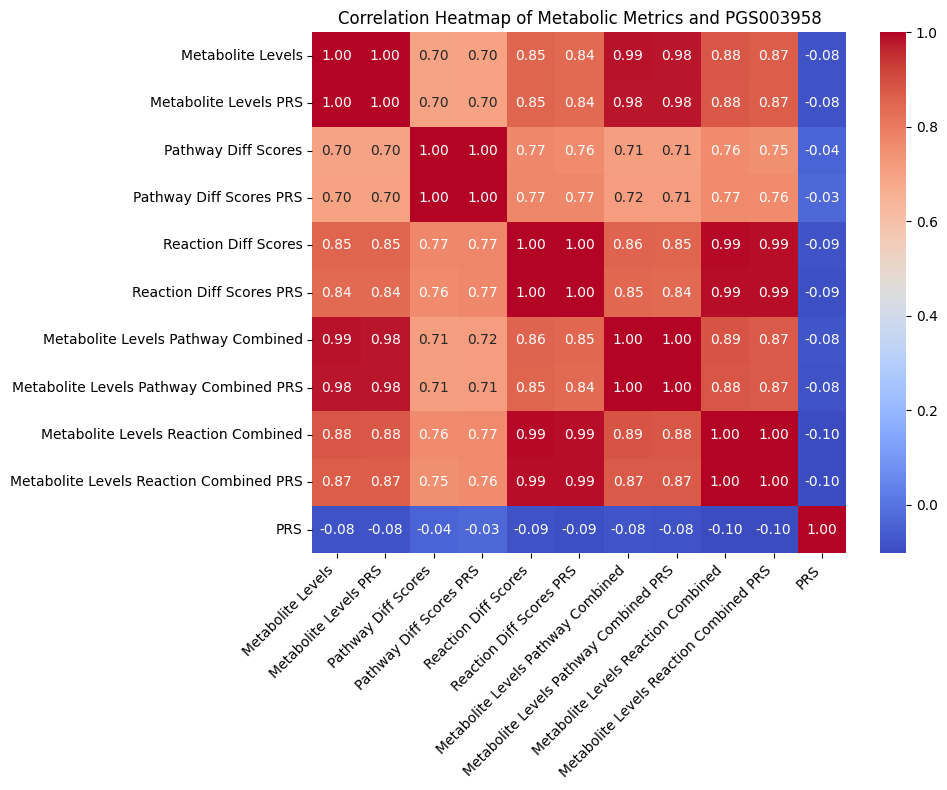

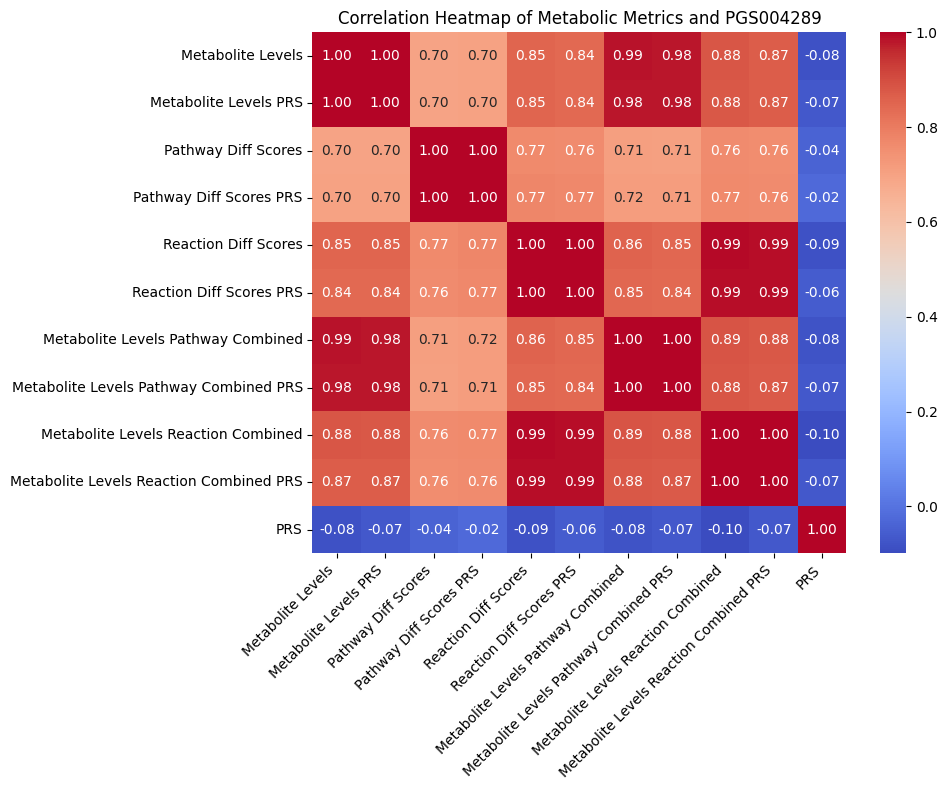

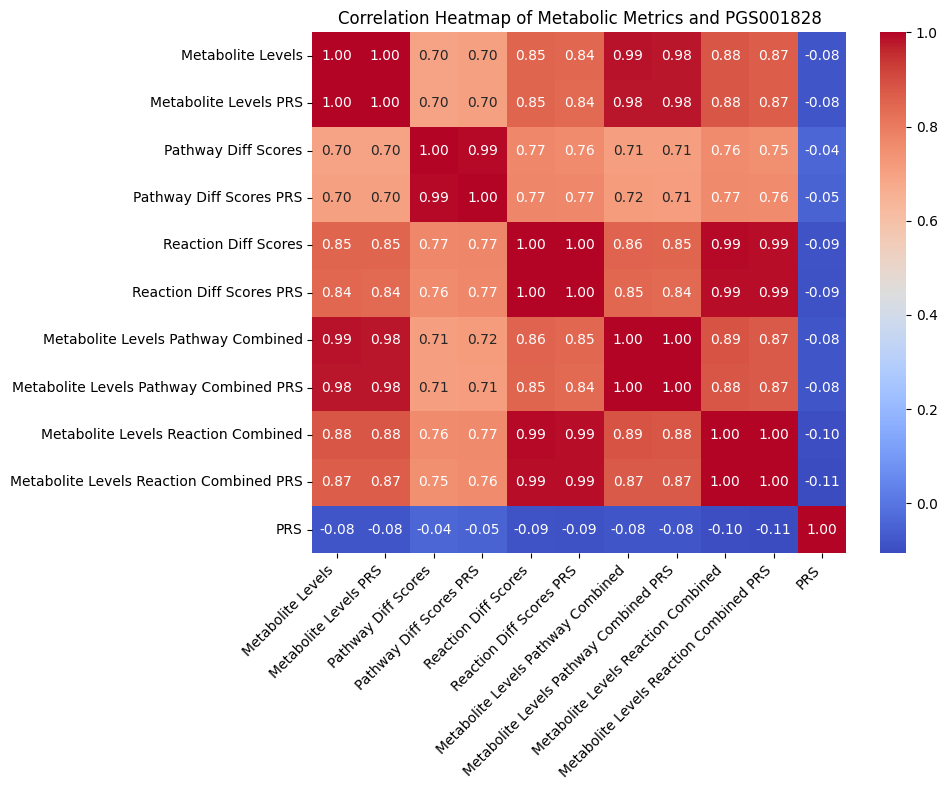

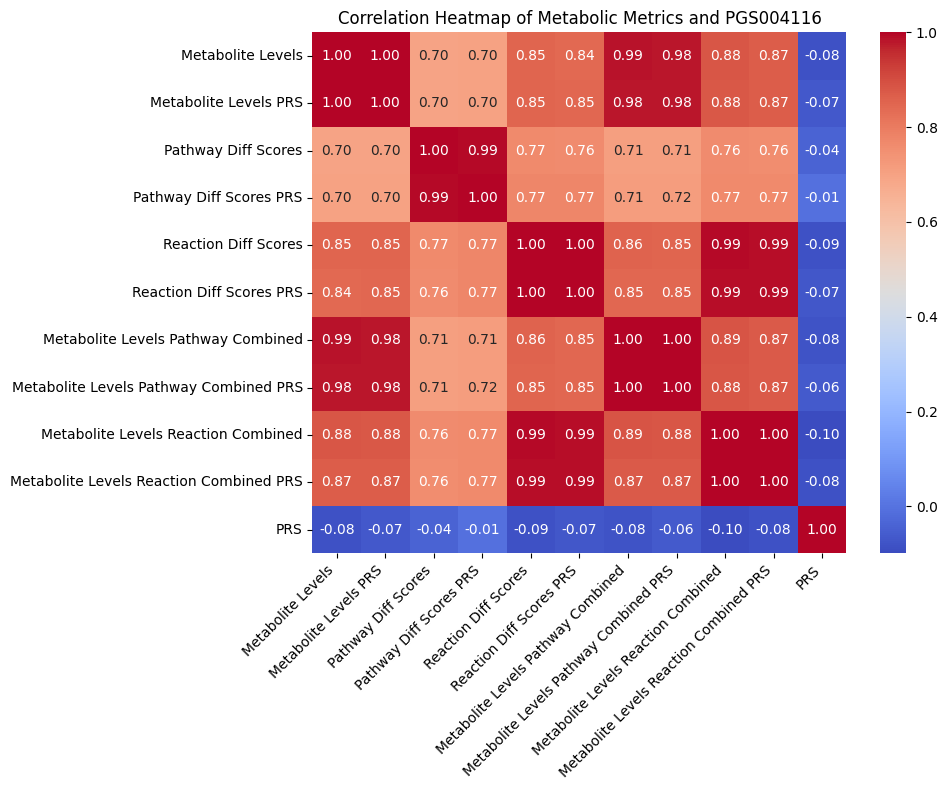

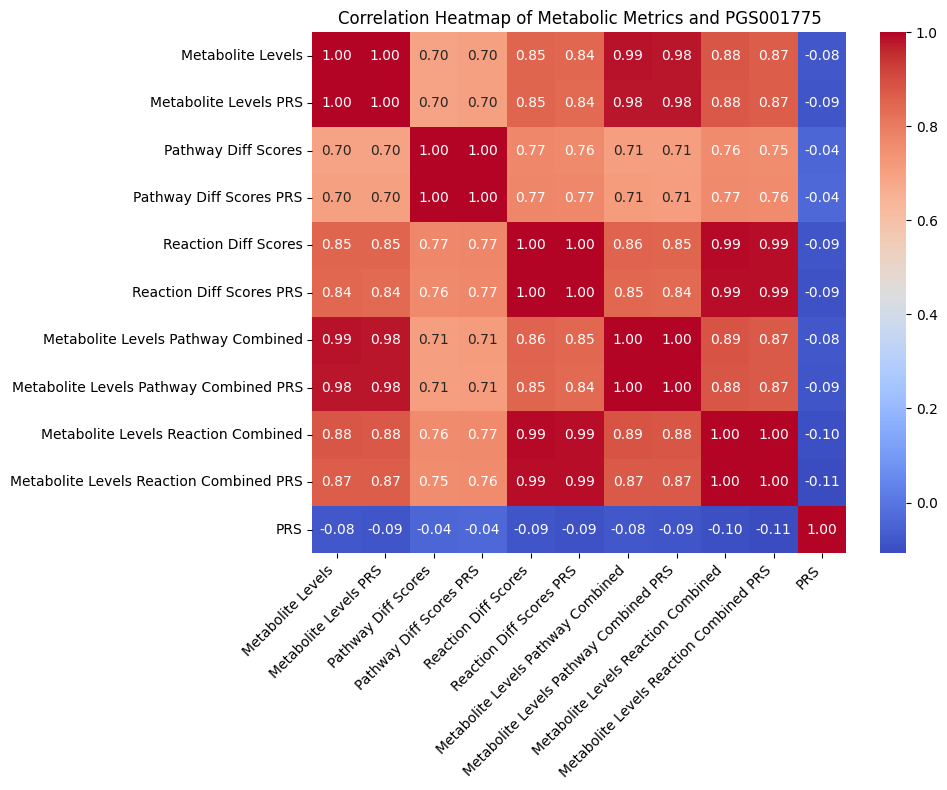

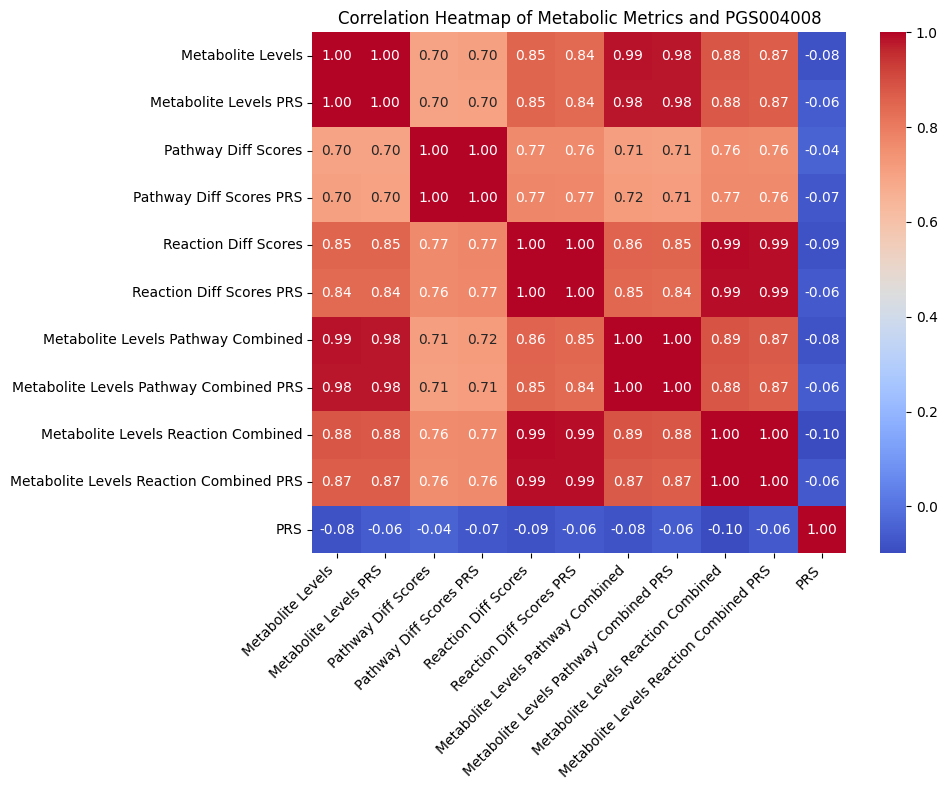

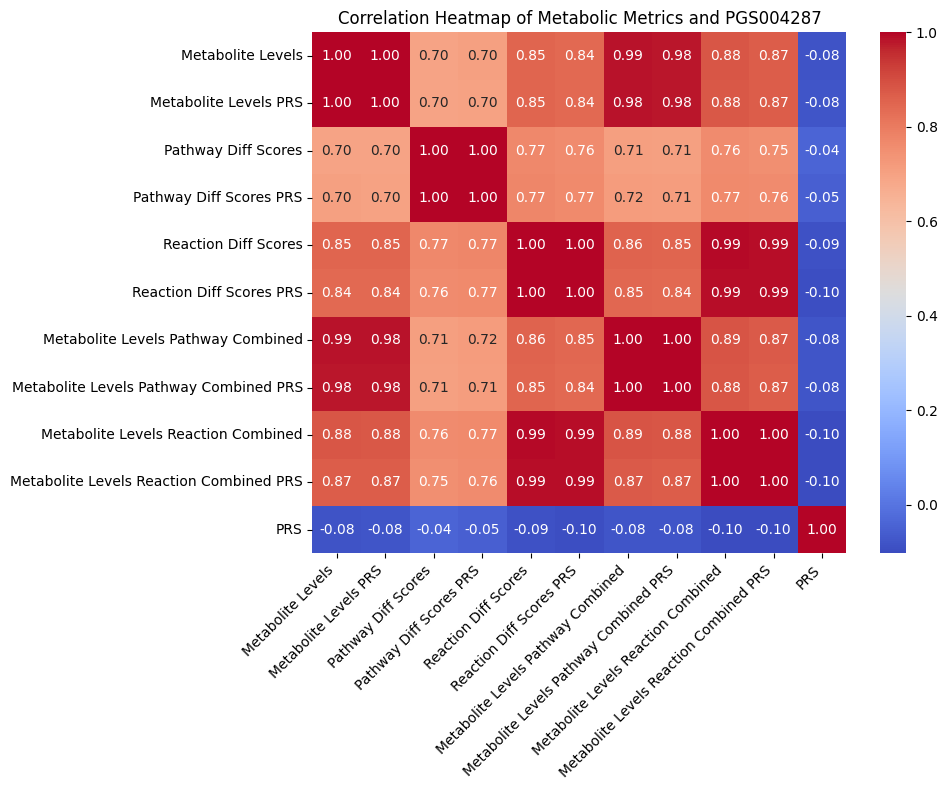

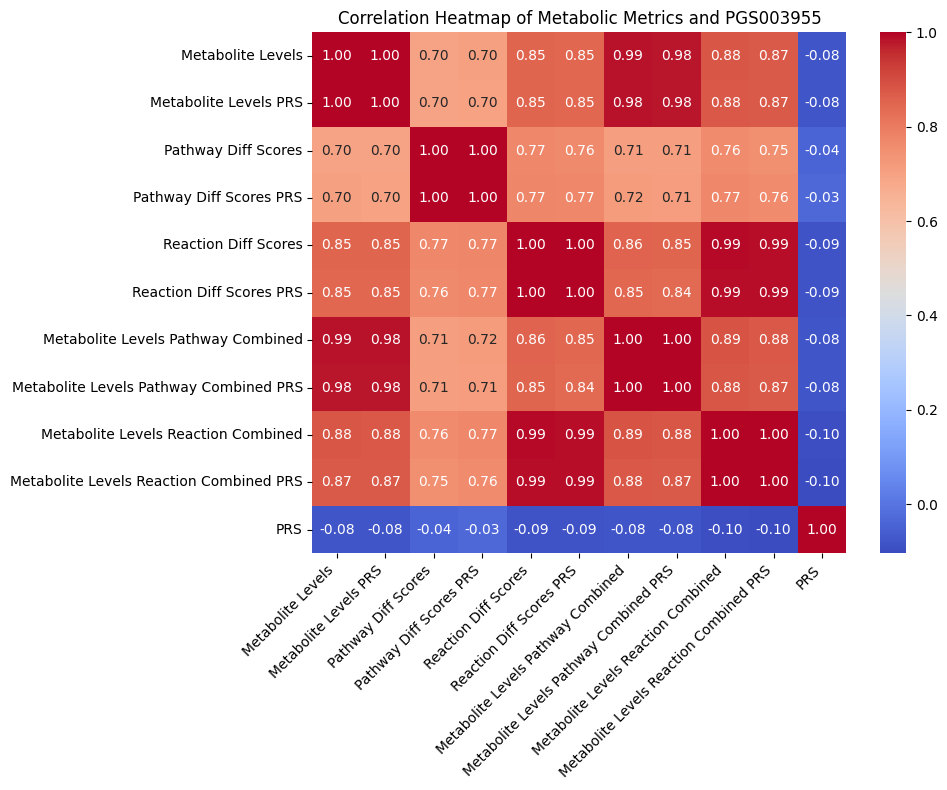

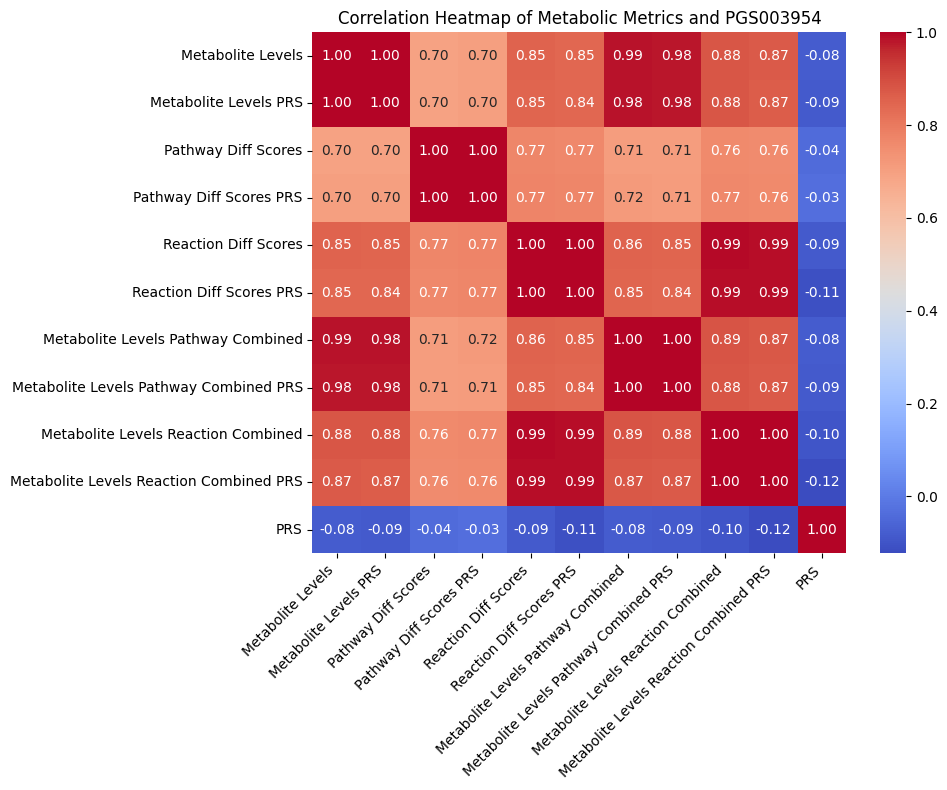

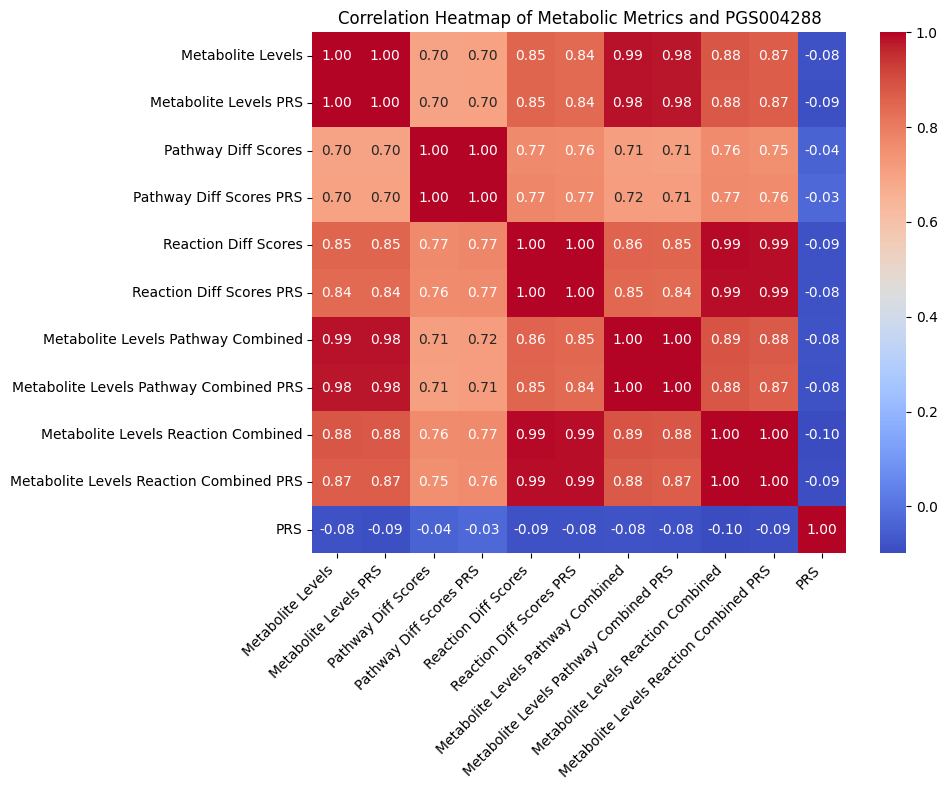

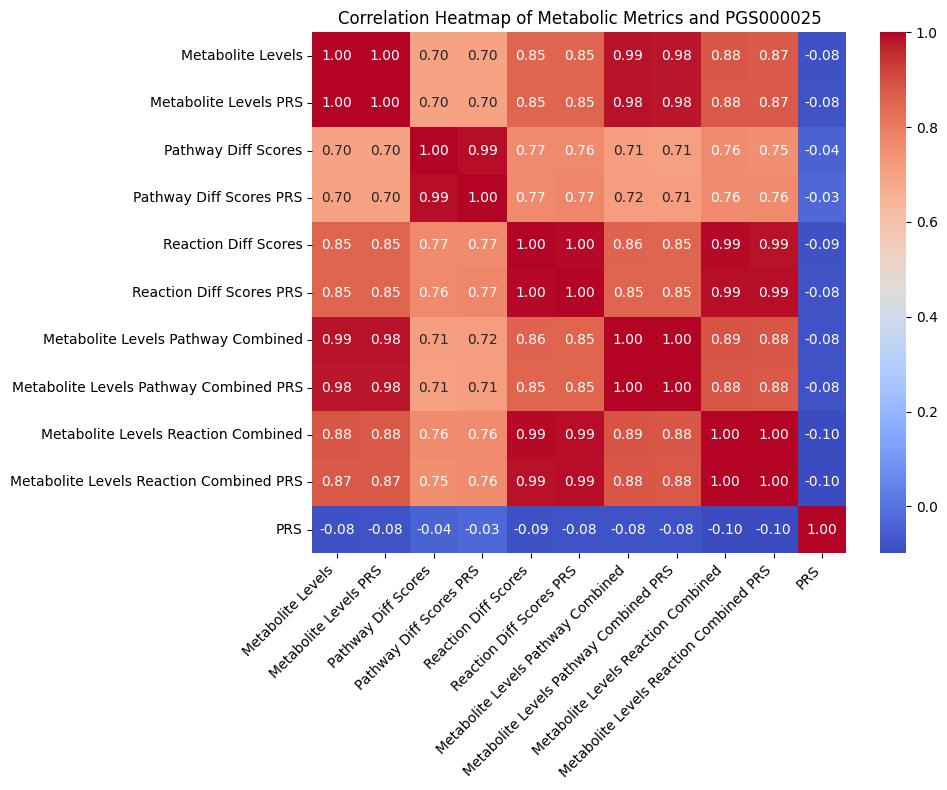

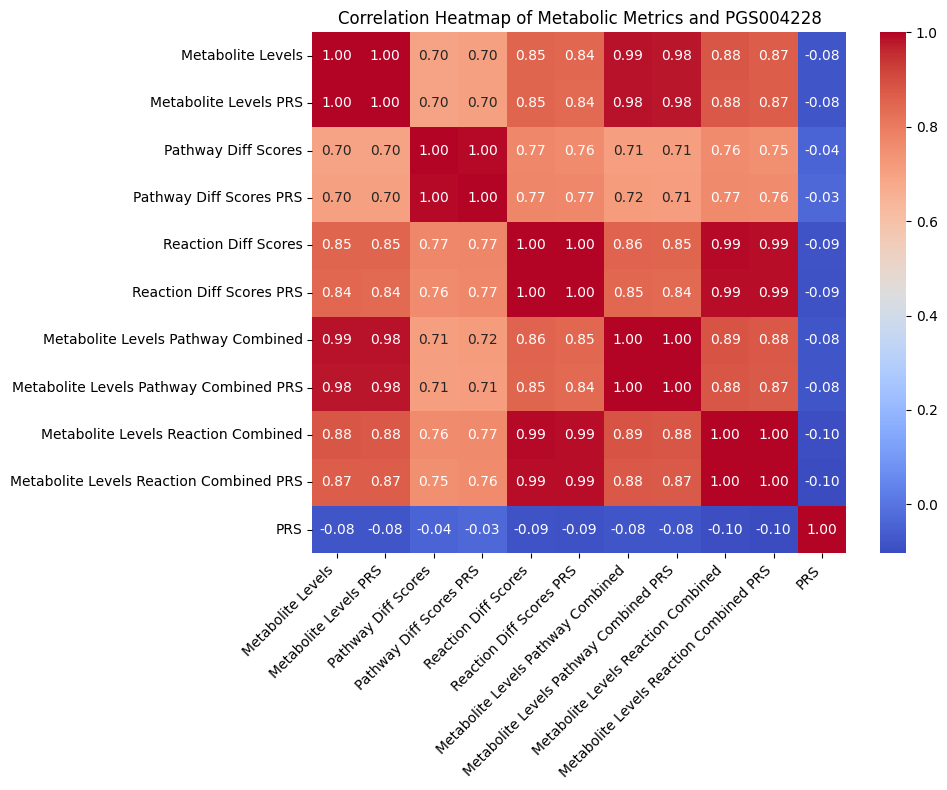

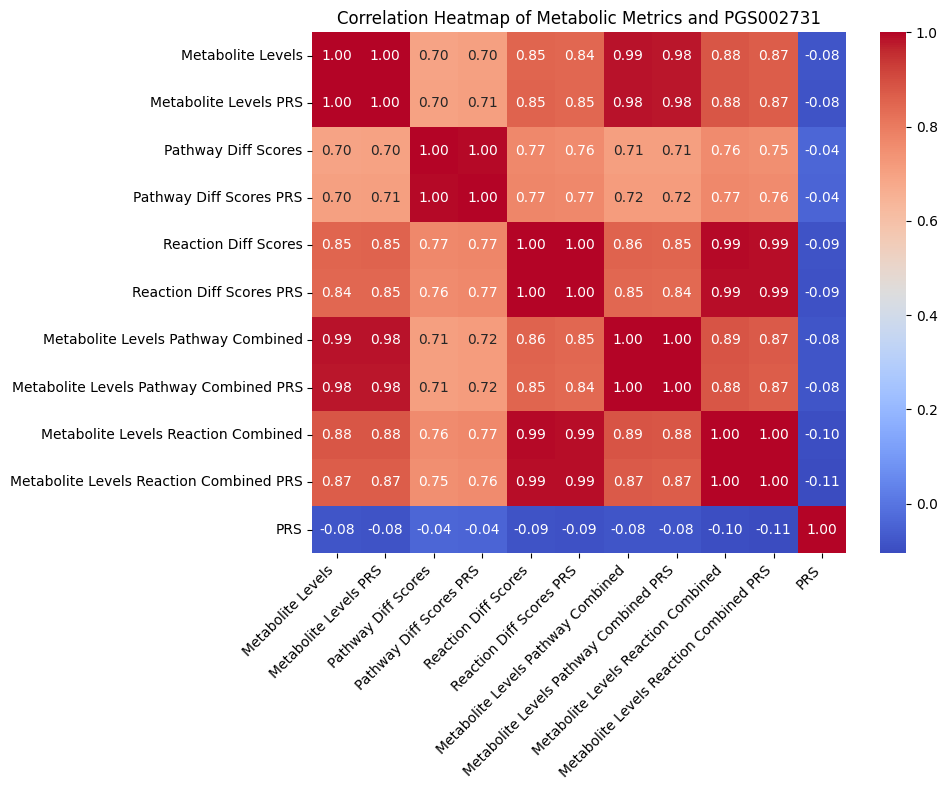

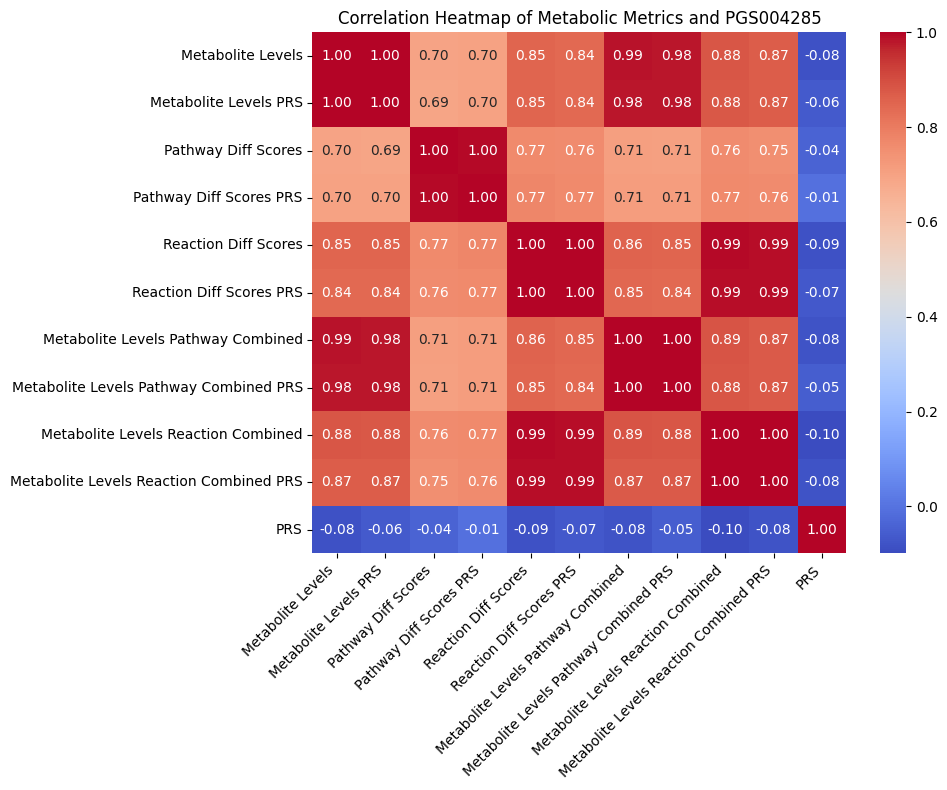

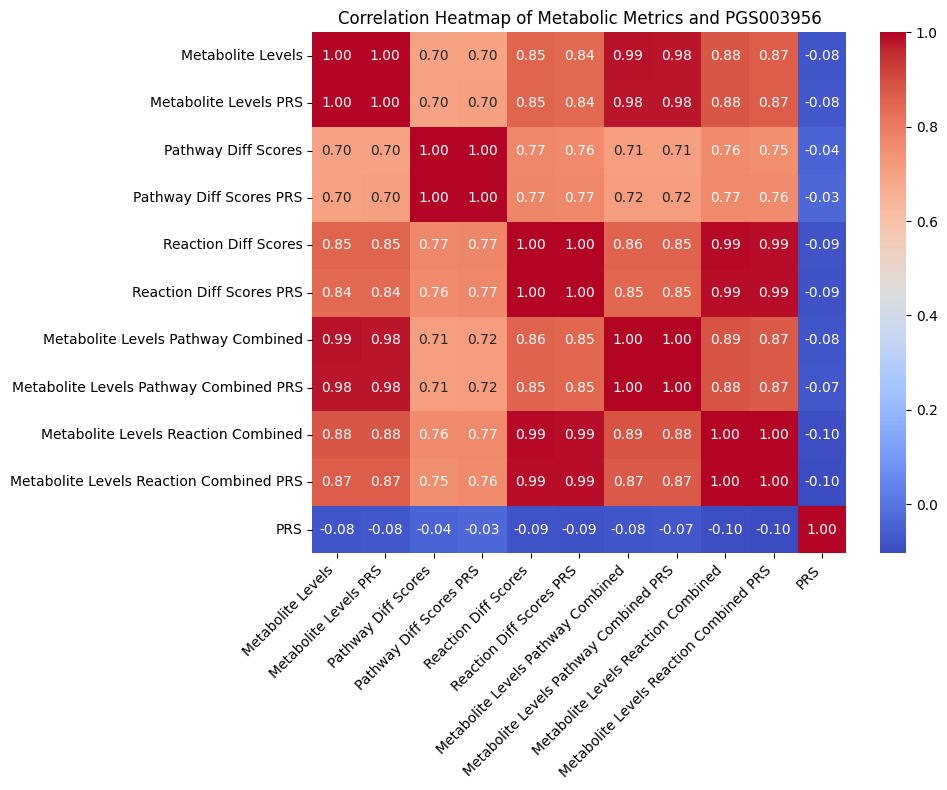

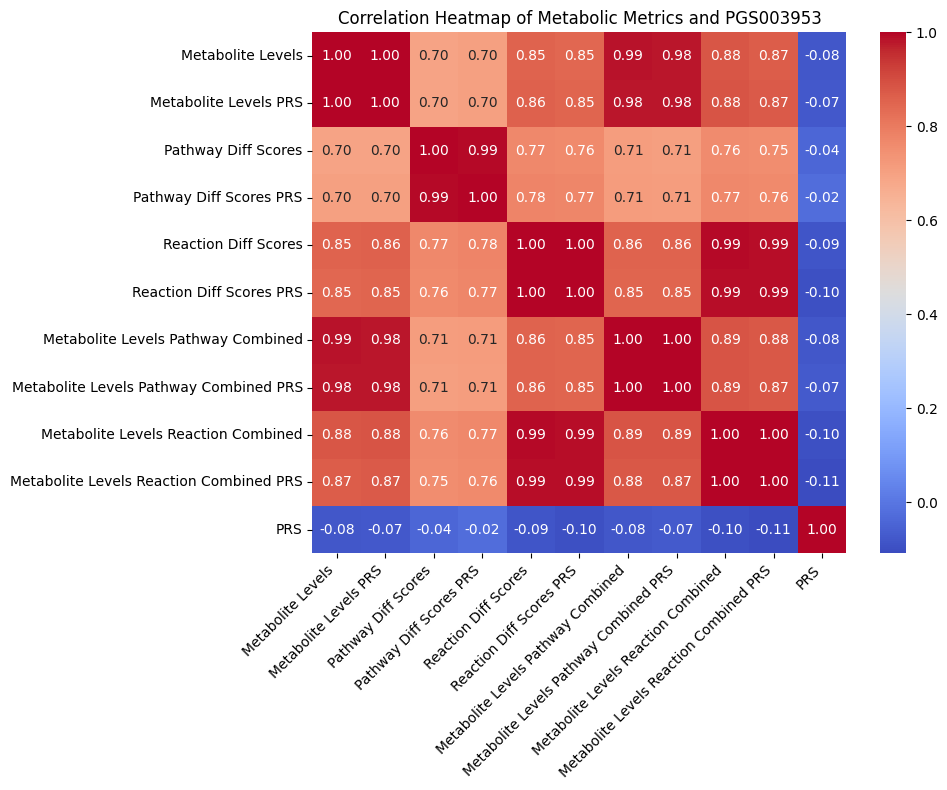

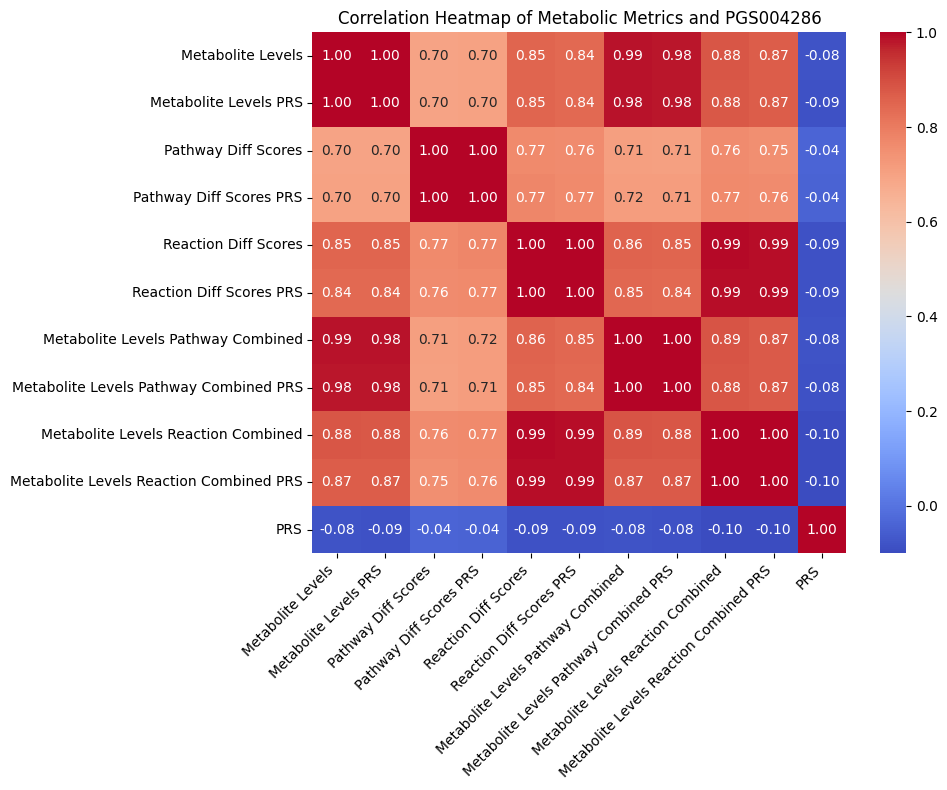

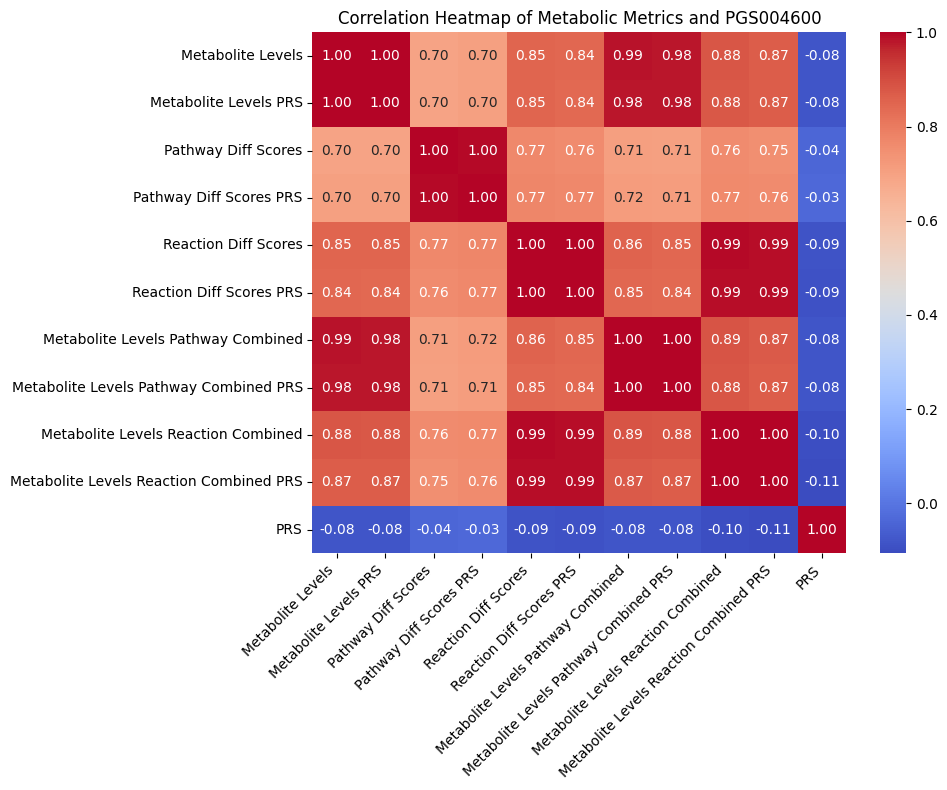

KeyError: 'PGS001349'

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

for subfolder in os.listdir(main_folder):
    if subfolder == '.DS_Store':
        continue
    df = df_dict[subfolder]
    df = df.drop(columns=['sample_id'])
    corr = df.corr()

    # Plot correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Correlation Heatmap of Metabolic Metrics and {subfolder}")
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
    plt.yticks(rotation=0)               # Keep y-axis labels horizontal
    plt.tight_layout()  # Adjust layout to fit everything nicely
    output_path = os.path.join("plots/heatmaps", f"correlation_heatmap{subfolder}.png")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, facecolor='white')  # Save with white background
    plt.show()